# 06 — CKD SHAP Explainability
**Final model:** Random Forest  
**Dataset:** Chronic Kidney Disease

## 1. Imports

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')

import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Absolute output path — avoids FileNotFoundError when savefig
# cannot resolve a relative path from the notebook working directory
OUTPUT_DIR = os.path.join(os.getcwd(), '..','outputs','ckd', 'SHAP')
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42

# Enable JS for interactive force plot in Jupyter
shap.initjs()

print('All imports successful.')
print(f'SHAP version : {shap.__version__}')
print(f'Output folder: {OUTPUT_DIR}')

All imports successful.
SHAP version : 0.51.0
Output folder: c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\ckd\SHAP


## 2. Load Data & Train Final Random Forest

In [28]:
# Load cleaned CKD dataset
ckd_df = pd.read_csv('../data/chronic_kidney_disease/ckd_cleaned.csv')

X = ckd_df.drop(columns=['classification'])
y = ckd_df['classification']   # 0 = Not CKD, 1 = CKD

print('Shape :', ckd_df.shape)
print('Target distribution:')
print(y.value_counts().rename({0: 'Not CKD', 1: 'CKD'}))

Shape : (400, 25)
Target distribution:
classification
CKD        250
Not CKD    150
Name: count, dtype: int64


In [29]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Train : 320 samples
Test  : 80 samples


In [30]:
# Build RF pipeline — SMOTE runs inside each CV fold (no leakage)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_pipeline = ImbPipeline([
    ('smote',      SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(
                       class_weight='balanced',
                       random_state=RANDOM_STATE,
                       n_jobs=-1
                   ))
])

rf_param_grid = {
    'classifier__n_estimators'     : [100, 200, 300],
    'classifier__max_depth'        : [5, 10, 15],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf' : [1, 2],
    'classifier__max_features'     : ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_

print('\nBest params  :', rf_grid.best_params_)
print('Best CV AUC  :', round(rf_grid.best_score_, 4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best params  : {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Best CV AUC  : 0.9998


In [31]:
# Quick test-set check
y_pred = rf_best.predict(X_test)
y_prob = rf_best.predict_proba(X_test)[:, 1]

print('Test Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Test ROC-AUC  :', round(roc_auc_score(y_test, y_prob), 4))
print()
print(classification_report(y_test, y_pred, target_names=['Not CKD', 'CKD']))

Test Accuracy : 1.0
Test ROC-AUC  : 1.0

              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



## 3. SHAP Explainer

Extract the fitted RF classifier from the pipeline and build `shap.TreeExplainer`.  
SHAP values are computed on the raw `X_test`.

In [32]:
# Step 1 — pull the fitted RF out of the pipeline
rf_clf = rf_best.named_steps['classifier']

# Step 2 — build the TreeExplainer
explainer = shap.TreeExplainer(rf_clf)

# Step 3 — compute SHAP values on the test set
# shap_values is a list of 2 arrays:
#   shap_values[0] → Not CKD (class 0)
#   shap_values[1] → CKD     (class 1)  ← we use this one
# Each array shape: (n_test_samples, n_features)
shap_values = explainer.shap_values(X_test)

print('Explainer               :', type(explainer))
print('Expected value (Not CKD):', round(explainer.expected_value[0], 4))
print('Expected value (CKD)    :', round(explainer.expected_value[1], 4))
print('shap_values[1] shape    :', np.array(shap_values[1]).shape,
      '  → (n_samples, n_features)')
print('Features                :', list(X_test.columns))

Explainer               : <class 'shap.explainers._tree.TreeExplainer'>
Expected value (Not CKD): 0.4999
Expected value (CKD)    : 0.5001
shap_values[1] shape    : (24, 2)   → (n_samples, n_features)
Features                : ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


## 4. Global Explanation — SHAP Summary Plot

Shows which features drive CKD predictions across **all** test patients.

- Each **dot** = one test patient  
- **Colour** = feature value (red = high, blue = low)  
- **X-axis** = SHAP value → right pushes toward CKD, left pushes away

In [33]:
# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# Fix for different SHAP versions
if isinstance(shap_values, list):
    shap_values_ckd = shap_values[1]
else:
    shap_values_ckd = shap_values[:, :, 1]

print("X_test shape       :", X_test.shape)
print("SHAP CKD shape     :", shap_values_ckd.shape)

X_test shape       : (80, 24)
SHAP CKD shape     : (80, 24)


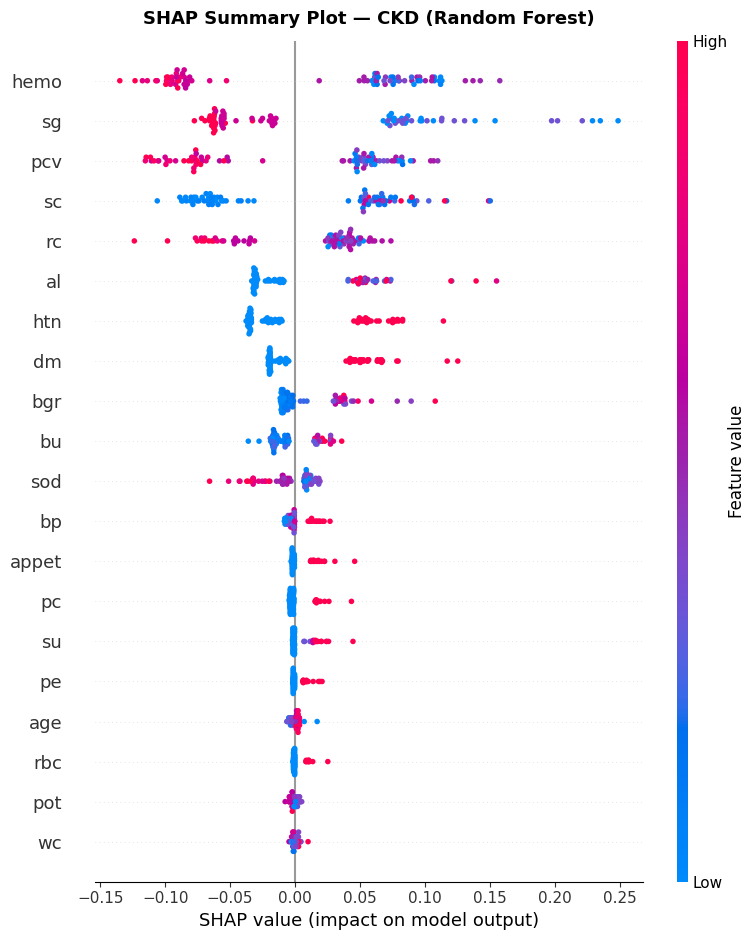

Saved → c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\ckd\SHAP/ckd_shap_summary_dot.png


In [34]:
plt.figure()

shap.summary_plot(
    shap_values_ckd,   # SHAP values for CKD class
    X_test,
    show=False
)

plt.title(
    'SHAP Summary Plot — CKD (Random Forest)',
    fontsize=13,
    fontweight='bold',
    pad=12
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ckd_shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved → {OUTPUT_DIR}/ckd_shap_summary_dot.png')

## 5. Feature Importance Bar Plot

Mean absolute SHAP value per feature — cleaner version for reports.

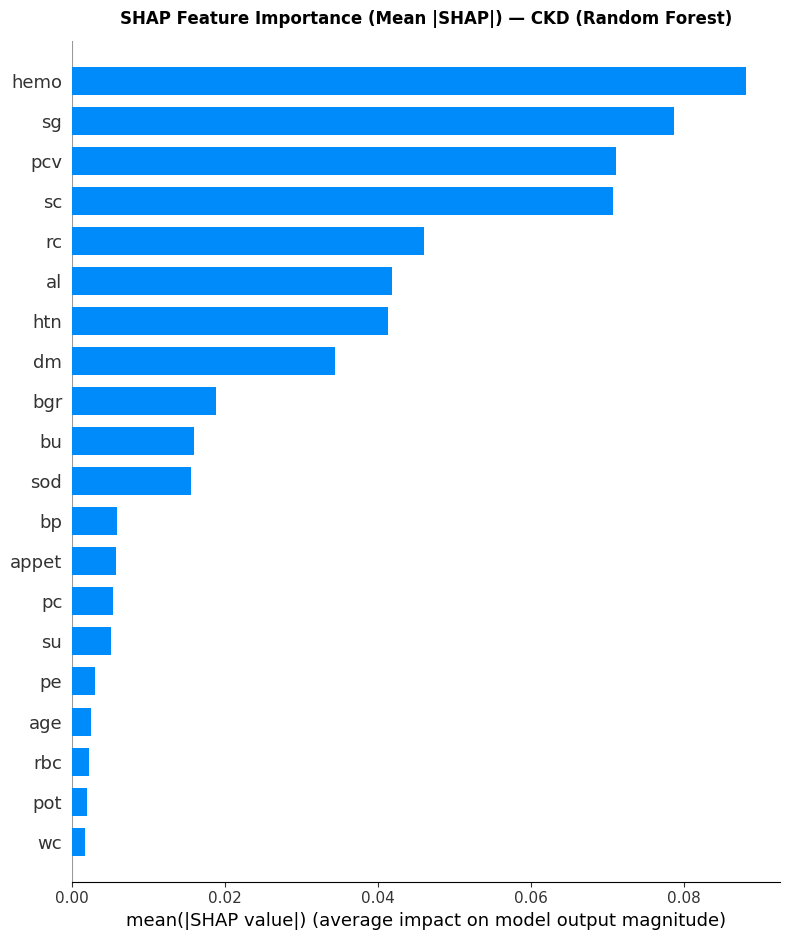

Saved → c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\ckd\SHAP/ckd_shap_feature_importance_bar.png

Ranked Feature Importance (Mean |SHAP|):
-----------------------------------
   1. hemo                0.0881
   2. sg                  0.0787
   3. pcv                 0.0711
   4. sc                  0.0708
   5. rc                  0.0460
   6. al                  0.0418
   7. htn                 0.0413
   8. dm                  0.0344
   9. bgr                 0.0188
  10. bu                  0.0159
  11. sod                 0.0156
  12. bp                  0.0059
  13. appet               0.0057
  14. pc                  0.0054
  15. su                  0.0050
  16. pe                  0.0030
  17. age                 0.0025
  18. rbc                 0.0022
  19. pot                 0.0020
  20. wc                  0.0017
  21. ane                 0.0012
  22. pcc                 0.0004
  23. cad                 0.0002


In [35]:
plt.figure()

shap.summary_plot(
    shap_values_ckd,
    X_test,
    plot_type='bar',
    show=False
)

plt.title(
    'SHAP Feature Importance (Mean |SHAP|) — CKD (Random Forest)',
    fontsize=12,
    fontweight='bold',
    pad=12
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ckd_shap_feature_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved → {OUTPUT_DIR}/ckd_shap_feature_importance_bar.png')

# Ranked table for reporting
mean_shap = pd.Series(
    np.abs(shap_values_ckd).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

print('\nRanked Feature Importance (Mean |SHAP|):')
print('-' * 35)

for rank, (feat, val) in enumerate(mean_shap.items(), 1):
    print(f'  {rank:>2}. {feat:<18}  {val:.4f}')

## 6. Local Explanation — Force Plot for One Patient

Explains **why** a single patient was predicted as CKD or Not CKD.

- **Red arrows** → features pushing toward CKD  
- **Blue arrows** → features pushing away from CKD  
- **Arrow width** → magnitude of contribution

In [36]:
# Patient info
patient_idx = 0

true_label = y_test.iloc[patient_idx]
pred_label = rf_best.predict(X_test.iloc[[patient_idx]])[0]
pred_prob  = rf_best.predict_proba(X_test.iloc[[patient_idx]])[0, 1]

print(f'Patient index     : {patient_idx}')
print(f'True label        : {"CKD" if true_label == 1 else "Not CKD"} ({true_label})')
print(f'Predicted label   : {"CKD" if pred_label == 1 else "Not CKD"} ({pred_label})')
print(f'P(CKD)            : {pred_prob:.4f}')
print(f'\nPatient feature values:')
print(X_test.iloc[patient_idx].to_frame(name='Value').to_string())

Patient index     : 0
True label        : Not CKD (0)
Predicted label   : Not CKD (0)
P(CKD)            : 0.0150

Patient feature values:
         Value
age      44.00
bp       60.00
sg        1.02
al        0.00
su        0.00
rbc       0.00
pc        0.00
pcc       0.00
ba        0.00
bgr      95.00
bu       46.00
sc        0.50
sod     138.00
pot       4.20
hemo     15.00
pcv      50.00
wc     7700.00
rc        6.30
htn       0.00
dm        0.00
cad       0.00
appet     0.00
pe        0.00
ane       0.00


In [37]:
# Prepare CKD SHAP values and expected value
if isinstance(shap_values, list):
    shap_values_ckd = shap_values[1]
    expected_value_ckd = explainer.expected_value[1]
else:
    shap_values_ckd = shap_values[:, :, 1]
    expected_value_ckd = explainer.expected_value[1]

print("CKD SHAP shape:", shap_values_ckd.shape)
print("Expected value CKD:", expected_value_ckd)

CKD SHAP shape: (80, 24)
Expected value CKD: 0.5000749999999986


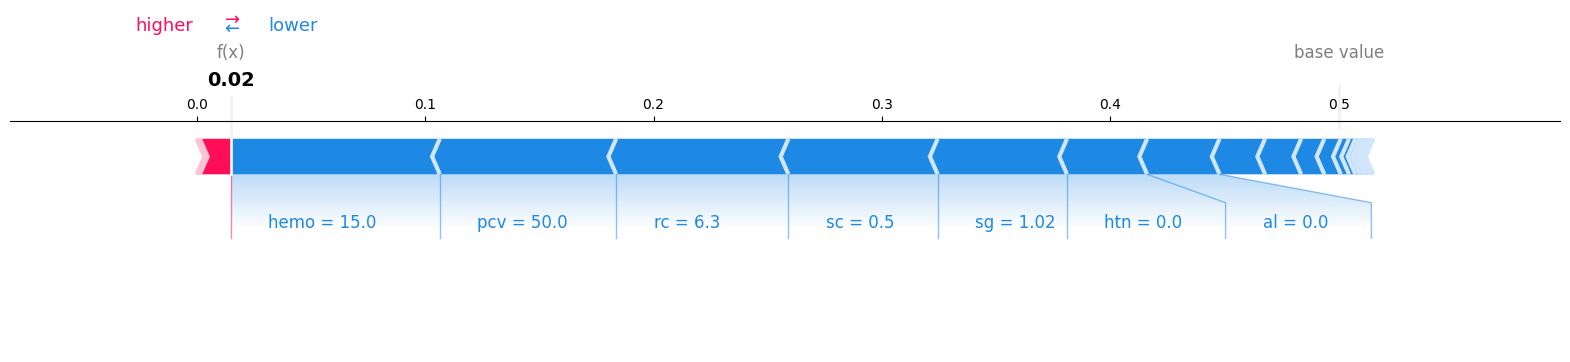

In [38]:
patient_idx = 0

shap.force_plot(
    expected_value_ckd,
    shap_values_ckd[patient_idx],
    X_test.iloc[patient_idx],
    matplotlib=True,
    show=False
)

plt.savefig(
    f"{OUTPUT_DIR}/ckd_shap_force_plot_patient0.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

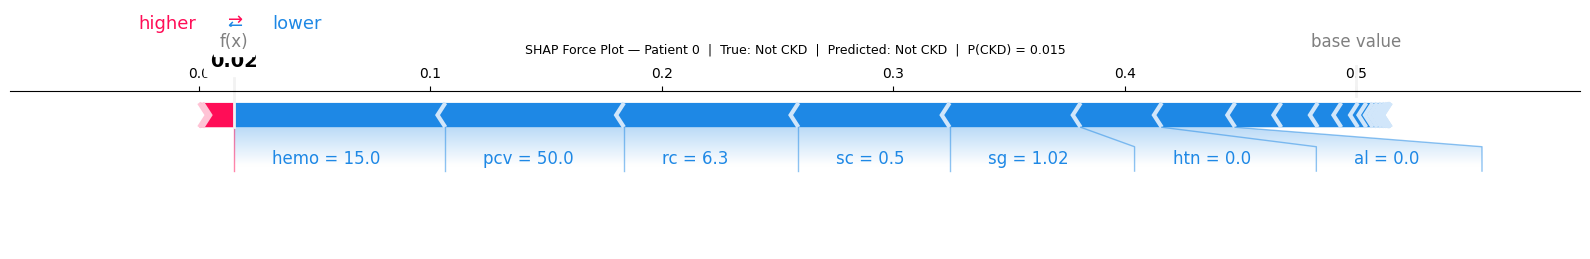

Saved → c:\Users\adwet\OneDrive\Documents\Production Project\explainable-disease-risk-prediction\notebooks\..\outputs\ckd\SHAP/ckd_shap_force_plot_patient0.png


In [39]:
# Static matplotlib version — saved to file for report
patient_idx = 0

plt.figure()

shap.force_plot(
    expected_value_ckd,
    shap_values_ckd[patient_idx],
    X_test.iloc[patient_idx],
    matplotlib=True,
    show=False,
    figsize=(16, 3)
)

plt.title(
    f'SHAP Force Plot — Patient {patient_idx}  |  '
    f'True: {"CKD" if true_label == 1 else "Not CKD"}  |  '
    f'Predicted: {"CKD" if pred_label == 1 else "Not CKD"}  |  '
    f'P(CKD) = {pred_prob:.3f}',
    fontsize=9,
    pad=10
)

plt.tight_layout()

save_path = f'{OUTPUT_DIR}/ckd_shap_force_plot_patient0.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved → {save_path}')